# Transfer Learning - Cats and Dogs classifier

In [1]:
import urllib
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras import layers, metrics, optimizers, Sequential
from keras import Model
from keras.applications.inception_v3 import InceptionV3

## Download and pre-process the data

In [2]:
import urllib.request
import zipfile

dataset_URL = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"
data_filename = "catsdogs.zip"
download_dir = 'data'

urllib.request.urlretrieve(url=dataset_URL, filename=data_filename)
zip_file = zipfile.ZipFile(data_filename, mode='r')
zip_file.extractall(download_dir)
zip_file.close()

In [3]:
# Check the number of examples in dataset

print("Number of cat images: ",{len(os.listdir("data/PetImages/Cat/"))})
print("Number of dog images: ",{len(os.listdir("data/PetImages/Dog/"))})

Number of cat images:  {12501}
Number of dog images:  {12501}


## Approach 1 - ImageDataGenerator

In [4]:
# Cleanup the data if
def remove_junk(base_dir):
    deleted = 0
    for root, dirs, files in os.walk(base_dir):
        for name in files:
            path = os.path.join(root, name)
            # Kill 0-byte files and non-image junk (.db, .txt, etc)
            if os.path.getsize(path) == 0 or not name.lower().endswith(('.jpg', '.jpeg')):
                os.remove(path)
                deleted += 1
    print(f"Cleaned {deleted} empty files.")

# Execute cleanup
remove_junk('data/PetImages')


Cleaned 4 empty files.


In [5]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.1
)

train_generator = datagen.flow_from_directory(
    "data/PetImages",
    batch_size=100,
    class_mode='binary',
    target_size=(150, 150),
    subset="training"
)

validation_generator = datagen.flow_from_directory(
    "data/PetImages",
    batch_size=100,
    class_mode='binary',
    target_size=(150, 150),
    subset="validation"
)

Found 22500 images belonging to 2 classes.
Found 2498 images belonging to 2 classes.


### Data Augmentation layers

In [6]:
augmentation_layers = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomZoom(height_factor=0.2, width_factor=0.2),
    layers.RandomRotation(factor=0.11),
    layers.RandomTranslation(height_factor=0.2, width_factor=0.2)
], name="Augmentation_layers")

### Base model for transfer Learning (InceptionV3)

In [7]:
# Inception model

base_inception_model = InceptionV3(include_top=False,
                                    input_shape=(150,150,3),
                                    weights="imagenet")

# Freeze layers in the inception model
for layer in base_inception_model.layers:
    layer.trainable = False

base_inception_model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 74, 74,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 74, 74,    │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 74, 74,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 72, 72,    │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 72, 72,    │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 72, 72,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 72, 72,    │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 72, 72,    │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 72, 72,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 35, 35,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 35, 35,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 33, 33,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 33, 33,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 33, 33,    │          0 │ batch_normalizat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 21,802,784 (83.17 MB)

In [8]:
last_layer_of_interest = base_inception_model.get_layer("mixed7")
print(f"Last layer output shape: {last_layer_of_interest.output.shape}")
last_output = last_layer_of_interest.output

Last layer output shape: (None, 7, 7, 768)


### Final model

In [9]:
input_layer = layers.Input(shape=(150,150,3))

# Augmentation
x = augmentation_layers(input_layer)

# Transfer Learning
# We want to get the output of the last layer of interest(mixed7) from Inception model
intermediate_model = Model(inputs = base_inception_model.input,
                            outputs = last_layer_of_interest.output, name="Inception_intermediate_model")
base_output = intermediate_model(x)

# Top layers
x = layers.Flatten()(base_output)
x = layers.Dense(1024, activation="relu")(x)
output_layer = layers.Dense(1, activation="sigmoid")(x)

model = Model(input_layer, output_layer)

In [10]:
# keras.utils.plot_model(model,
#                         show_shapes=True,
#                         show_layer_names=True,
#                         dpi=96)

model.summary(expand_nested=True, show_trainable=True)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 150, 150, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ Augmentation_layers         │ (None, 150, 150, 3)   │          0 │   -   │
│ (Sequential)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └ random_flip            │ (None, 150, 150, 3)   │          0 │   -   │
│ (RandomFlip)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └ random_zoom            │ (None, 150, 150, 3)   │          0 │   -   │
│ (RandomZoom)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └ random_rotation        │ (None, 150, 150, 3)   │          0 │   -   │
│ (RandomRotation)            │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └ random_translation     │ (None, 150, 150, 3)   │          0 │   -   │
│ (RandomTranslation)         │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ Inception_intermediate_mod… │ (None, 7, 7, 768)     │  8,975,264 │   Y   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └ input_layer            │ (None, 150, 150, 3)   │          0 │   -   │
│ (InputLayer)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └ conv2d (Conv2D)        │ (None, 74, 74, 32)    │        864 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └ batch_normalization    │ (None, 74, 74, 32)    │         96 │   N   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └ activation             │ (None, 74, 74, 32)    │          0 │   -   │
│ (Activation)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └ conv2d_1 (Conv2D)      │ (None, 72, 72, 32)    │      9,216 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └ batch_normalization_1  │ (None, 72, 72, 32)    │         96 │   N   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └ activation_1           │ (None, 72, 72, 32)    │          0 │   -   │
│ (Activation)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └ conv2d_2 (Conv2D)      │ (None, 72, 72, 64)    │     18,432 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └ batch_normalization_2  │ (None, 72, 72, 64)    │        192 │   N   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └ activation_2           │ (None, 72, 72, 64)    │          0 │   -   │
│ (Activation)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│    └ max_pooling2d          │ (None, 35, 35, 64)    │          0 │   -   │
│ (MaxPooling2D)              │                       │            │     

 Total params: 47,512,481 (181.25 MB)

 Trainable params: 38,537,217 (147.01 MB)

 Non-trainable params: 8,975,264 (34.24 MB)

### Compile and train the model

In [11]:
# Compile the model
model.compile(optimizer=optimizers.RMSprop(learning_rate=0.0001), #type: ignore
                loss="binary_crossentropy",
                metrics=['accuracy'])

# Training
history = model.fit(train_generator,
                    validation_data=validation_generator,
                    epochs=20,
                    verbose=1)

Epoch 1/20
132/225 ━━━━━━━━━━━━━━━━━━━━ 17s 191ms/step - accuracy: 0.8267 - loss: 0.4526

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


225/225 ━━━━━━━━━━━━━━━━━━━━ 61s 225ms/step - accuracy: 0.8943 - loss: 0.2517 - val_accuracy: 0.9668 - val_loss: 0.0790
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 45s 201ms/step - accuracy: 0.9264 - loss: 0.1768 - val_accuracy: 0.9524 - val_loss: 0.1123
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 46s 203ms/step - accuracy: 0.9289 - loss: 0.1624 - val_accuracy: 0.9680 - val_loss: 0.0725
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 49s 218ms/step - accuracy: 0.9352 - loss: 0.1562 - val_accuracy: 0.9668 - val_loss: 0.0748
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 46s 203ms/step - accuracy: 0.9384 - loss: 0.1460 - val_accuracy: 0.9712 - val_loss: 0.0727
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 45s 200ms/step - accuracy: 0.9409 - loss: 0.1424 - val_accuracy: 0.9696 - val_loss: 0.0727
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 45s 200ms/step - accuracy: 0.9396 - loss: 0.1407 - val_accuracy: 0.9708 - val_loss: 0.0732
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 47s 210ms/step - accuracy: 0.9445 - loss: 0.1355 - val

### Plot the training results

<Figure size 640x480 with 0 Axes>

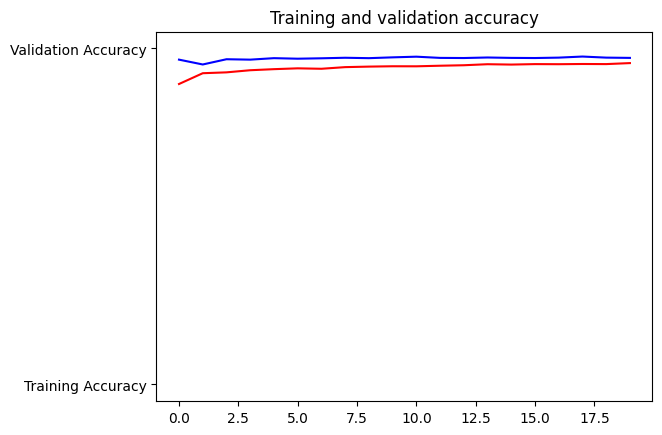

<Figure size 640x480 with 0 Axes>

In [14]:
%matplotlib inline

import matplotlib.image  as mpimg
import matplotlib.pyplot as plt

#-----------------------------------------------------------
# Retrieve a list of list results on training and test data
# sets for each training epoch
#-----------------------------------------------------------
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

epochs=range(len(acc)) # Get number of epochs

#------------------------------------------------
# Plot training and validation accuracy per epoch
#------------------------------------------------
plt.plot(epochs, acc, 'r', "Training Accuracy")
plt.plot(epochs, val_acc, 'b', "Validation Accuracy")
plt.title('Training and validation accuracy')
plt.figure()